Text(0.5, 0.92, 'Perception Error Surface\n(Linearly Seperable Case)')

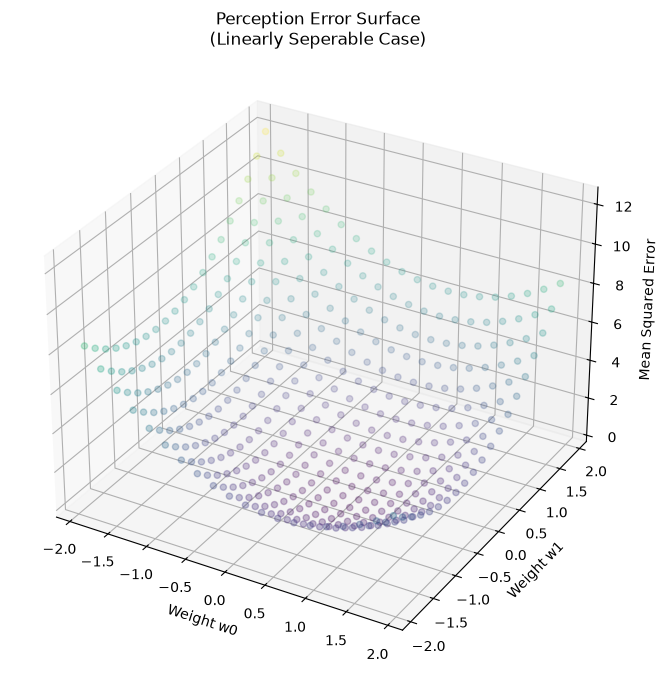

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

X = np.array([[-1,-1],[-1,1],[1,-1],[1,1]])
y = np.array([[-1],[1],[1],[1]])

w0_range = np.arange(-1.9,2.0,0.2)
w1_range = np.arange(-1.9,2.0,0.2)
b=1

# Initialize lists to sotre results

w0_points = []
w1_points = []
error_points = []


#compute error for weight combination

for w0 in w0_range:
    for w1 in w1_range:
        y_hat = X[:,0]*w0 + X[:,1]+w1 + b 
        error = np.mean((y.ravel() - y_hat)**2)

        # store the results
        w0_points.append(w0)
        w1_points.append(w1)
        error_points.append(error)


w0_points = np.array(w0_points)
w1_points = np.array(w1_points)
error_points = np.array(error_points)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

#create 3d graph 

scatter = ax.scatter(w0_points, w1_points, error_points,
                     c=error_points, cmap='viridis',
                     alpha=0.6, s=20)

#add labels

ax.set_xlabel('Weight w0')
ax.set_ylabel('Weight w1')
ax.set_zlabel('Mean Squared Error')
ax.set_title('Perception Error Surface\n(Linearly Seperable Case)')


In [7]:
import torch 
import torch.nn as nn
import torch.optim as optim

X= torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
y = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x
    
# initialize network, loss and optimizer
# weights are chosen randomly, 

model = XORNet()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X)
    loss=criterion(outputs, y)
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')


print("\nResults")

with torch.no_grad():
    for i in range(len(X)):
        output = model(X[i])
        print(f'Input: {X[i].numpy()}, Predicted Output: {y[i].item()}, Actual Output: {output.item():.4f}')



Epoch 1, Loss: 0.2498

Results
Input: [0. 0.], Predicted Output: 0.0, Actual Output: 0.0088
Input: [0. 1.], Predicted Output: 1.0, Actual Output: 0.9923
Input: [1. 0.], Predicted Output: 1.0, Actual Output: 0.9895
Input: [1. 1.], Predicted Output: 0.0, Actual Output: 0.0083
